# Protocol v3 Redesign Notebook (Paper-Ready Evaluation)

This notebook evaluates a constrained v3 protocol design for LP downside hedging under a clear, reproducible methodology.

Design constraints used throughout:

1. **Cover ratio is fixed to full cover** (`cover = 1`).
2. **Barrier is fixed to CL lower bound** (`B = p_l`).
3. **Position width is fixed to `+-7.5%`**.
4. **Real market data only**: Birdeye SOL daily data is required; if fetch fails, execution stops.

Primary evaluation focus:

- **Break-even fee-yield** needed to make each strategy non-negative on mean return.
- **Strategy ranking by break-even fee-yield** (lower required fee-yield is better).
- For protocol LP hedger: break-even must satisfy **joint LP+RT viability**.

Research Questions:

1. What product definition and pricing mechanism are mathematically consistent for LP downside transfer?
2. Which protocol `yield_split` values admit joint LP+RT viability, and at what break-even LP fee-yield?
3. How does protocol break-even compare with alternative hedging strategies (fixed perp, dynamic perp, plain LP)?



## 1) Product Formalization (Mathematical + Intuitive)

### 1.1 CL position geometry

At weekly entry price `S0`, with fixed width `w = 7.5%`:

- `p_l = S0(1-w)`
- `p_u = S0(1+w)`
- by design, `B = p_l`

So the protocol does not optimize depth separately; depth is the LP lower bound.

### 1.2 Corridor payout

Let `V(S)` be CL position value at spot `S`. Weekly payout to LP is:

$$
\Pi(S_T)=\min\left(Cap,\max\left(0, V(S_0)-V(\max(S_T,B))ight)ight)
$$

with

$$
Cap = V(S_0)-V(B), \quad B=p_l.
$$

Interpretation:

- If final spot `S_T` stays above entry, payout is ~0.
- If `S_T` drops, payout compensates LP CL-value loss.
- Compensation is capped at `Cap` (loss down to barrier).

### 1.3 Premium rule

Weekly premium charged to LP:

$$
Premium = \max\left(0, FV\cdot m_{vol} - y_{split}\cdot E[Fees]ight)
$$

where:

- `FV`: risk-neutral fair value of corridor payout,
- `m_vol`: IV/RV-style markup proxy,
- `y_split`: fee share transferred to RT,
- `E[Fees]`: expected weekly LP fee income.

### 1.4 LP and RT weekly PnL identities

LP:

$$
	ext{LP PnL}=(V_T-V_0)+	ext{fees}_{LP}+\Pi-	ext{premium}-	ext{exec cost}
$$

RT:

$$
	ext{RT PnL}=	ext{premium}_{net}+	ext{fee share}-\Pi
$$

Joint viability condition in this notebook is:

- `E[LP return] >= 0` and `E[RT return] >= 0`.

### 1.5 Concrete example (qualitative)

Suppose `S0=100`, width `+-7.5%` => `p_l=92.5`, `p_u=107.5`, barrier `B=92.5`.

- If week ends at `S_T=104`, payout is near zero (little downside to insure).
- If week ends at `S_T=90`, corridor activates and pays LP up to the capped loss-from-entry-to-barrier profile.
- Whether LP and RT are both viable depends on premium level, realized fees, and path distribution.



## 2) Methodology (Defensible Core)

### 2.1 Data and simulation regime

- Real historical SOL daily prices from Birdeye (required).
- Weekly Monte Carlo via historical block bootstrap (8-day windows), preserving volatility clustering better than iid Gaussian.

### 2.2 Strategy set

- `protocol_lp` (LP hedger + RT underwriter economics)
- `perp_fixed_lp` (fixed 50% initial SOL hedge)
- `perp_dynamic_lp` (rebalance hedge by range-decile move)
- `plain_lp` (no derivative/perp hedge)

### 2.3 Cost and fee assumptions

Perp costs are modeled with fixed assumptions in this notebook:

- transaction cost: `2 bps` per hedge trade,
- funding cost: `1 bp/day`, treated conservatively as a cost.

LP fee accrual is modeled consistently across LP-based strategies with strict in-range logic:

- in range => multiplier `1.0`
- out of range => multiplier `0.0`

### 2.4 Two break-even definitions used

1. **Protocol joint break-even fee-yield** (per `yield_split`):
   minimum `fee_day` such that `E[LP]>=0` and `E[RT]>=0`.
2. **Strategy LP break-even fee-yield** (`plain/perp`):
   minimum `fee_day` such that `E[LP]>=0`.

### 2.5 Ranking criterion

Rank strategies by required break-even `fee_day` (lower is better). For protocol ranking, use the **best jointly feasible** `yield_split`.



In [1]:
import os, json, math
import numpy as np
from scipy.special import ndtr
import pandas as pd
import matplotlib.pyplot as plt
from numpy.polynomial.hermite import hermgauss
from urllib.request import urlopen
from urllib.parse import urlencode

from pathlib import Path

def resolve_data_dir():
    # Robust against different notebook working directories.
    # Prefer the real repo root by checking for lh-protocol-v3/protocol-src.
    here = Path.cwd().resolve()
    for parent in [here, *here.parents]:
        repo = parent / 'lh-protocol-v3'
        if (repo / 'protocol-src').exists():
            cand = repo / 'notebooks' / 'data'
            cand.mkdir(parents=True, exist_ok=True)
            return str(cand)
    # Fallback: local ./data
    fallback = here / 'data'
    fallback.mkdir(parents=True, exist_ok=True)
    return str(fallback)

DATA_DIR = resolve_data_dir()
os.makedirs(DATA_DIR, exist_ok=True)
rng = np.random.default_rng(42)

print('Environment ready.')


Environment ready.


In [2]:
# 3) Data loader (historical spot for bootstrap/backtest)

import os
import time
import requests

# Real data only for paper-ready evaluation
BIRDEYE_API_KEY = os.getenv('BIRDEYE_API_KEY', '').strip() or 'ed577a4a6a4f480fa659b4f18673e4b1'
SOL_MINT = 'So11111111111111111111111111111111111111112'

def fetch_birdeye_daily_sol(days=1150, chunk_days=90):
    if not BIRDEYE_API_KEY:
        raise RuntimeError('BIRDEYE_API_KEY is missing.')

    now = int(time.time())
    start = now - int(days) * 24 * 3600
    rows = []

    url = 'https://public-api.birdeye.so/defi/ohlcv'
    headers = {'X-API-KEY': BIRDEYE_API_KEY, 'Accept': 'application/json', 'x-chain': 'solana'}

    cur = start
    while cur < now:
        nxt = min(cur + int(chunk_days) * 24 * 3600, now)
        params = {
            'address': SOL_MINT,
            'type': '1D',
            'time_from': int(cur),
            'time_to': int(nxt),
        }
        r = requests.get(url, params=params, headers=headers, timeout=20)
        r.raise_for_status()
        js = r.json()

        if not bool(js.get('success', False)):
            raise RuntimeError(f'Birdeye request failed for [{cur}, {nxt}]: {js}')

        items = js.get('data', {}).get('items', [])
        if not isinstance(items, list):
            raise RuntimeError('Unexpected Birdeye schema: data.items is not a list')

        rows.extend(items)
        cur = nxt

    if len(rows) == 0:
        raise RuntimeError('Birdeye returned empty OHLCV items')

    df = pd.DataFrame(rows)
    if 'unixTime' in df.columns:
        ts = pd.to_datetime(df['unixTime'], unit='s', utc=True)
    elif 'startUnixTime' in df.columns:
        ts = pd.to_datetime(df['startUnixTime'], unit='s', utc=True)
    else:
        raise RuntimeError(f'Unexpected Birdeye columns: {list(df.columns)}')

    if 'c' in df.columns:
        close = pd.to_numeric(df['c'], errors='coerce')
    elif 'close' in df.columns:
        close = pd.to_numeric(df['close'], errors='coerce')
    else:
        raise RuntimeError(f'Unexpected Birdeye close columns: {list(df.columns)}')

    out = (pd.DataFrame({'open_time': ts, 'close': close})
           .dropna()
           .drop_duplicates('open_time')
           .sort_values('open_time')
           .reset_index(drop=True))

    if len(out) < 365:
        raise RuntimeError(f'Birdeye returned too few daily points ({len(out)}).')

    return out

hist = fetch_birdeye_daily_sol(days=1150, chunk_days=90)
closes = hist['close'].to_numpy(float)
src = 'birdeye_SOL_daily'

print('Source:', src)
print('Data points:', len(closes))



Source: birdeye_SOL_daily
Data points: 1150


In [3]:
# 4) Core CL and product math (fixed width, fixed barrier=lower bound)

WIDTH = 0.075
T_WEEK = 7/365
N_LIQ = 10_000.0
PROTOCOL_FEE_RATE = 0.015


def cl_value(S, L, p_l, p_u):
    S = np.asarray(S, float)
    sp, spl, spu = np.sqrt(np.clip(S, 1e-12, None)), np.sqrt(p_l), np.sqrt(p_u)
    below = S <= p_l
    above = S >= p_u
    a = np.where(below, L*(spu-spl)/(spl*spu), np.where(above, 0.0, L*(spu-sp)/(sp*spu)))
    b = np.where(below, 0.0, np.where(above, L*(spu-spl), L*(sp-spl)))
    return a*S + b


def make_pos(S0, lev=1.0):
    p_l, p_u = S0*(1-WIDTH), S0*(1+WIDTH)
    B = p_l  # by design
    L = N_LIQ*lev
    V0 = float(cl_value(np.array([S0]), L, p_l, p_u)[0])
    Vb = float(cl_value(np.array([B]), L, p_l, p_u)[0])
    cap = max(0.0, V0 - Vb)
    return {'p_l': p_l, 'p_u': p_u, 'B': B, 'L': L, 'V0': V0, 'cap': cap}


def corridor_payoff(S_T, S0, pos):
    V_eff = cl_value(np.maximum(S_T, pos['B']), pos['L'], pos['p_l'], pos['p_u'])
    raw = np.maximum(0.0, np.where(S_T >= S0, 0.0, pos['V0'] - V_eff))
    return np.minimum(pos['cap'], raw)


# Cached Gauss-Hermite nodes/weights (avoid recomputing inside MC loops)
QUAD_N = 48
QUAD_NODES, QUAD_WEIGHTS = hermgauss(QUAD_N)

def fv_quadrature(S0, sigma, pos, T=T_WEEK):
    S_T = S0*np.exp(-0.5*sigma**2*T + sigma*np.sqrt(T)*QUAD_NODES*np.sqrt(2))
    pay = corridor_payoff(S_T, S0, pos)
    return max(0.0, float(np.sum(QUAD_WEIGHTS*pay)/np.sqrt(np.pi)))


# IV/RV-style effective markup (v3/v4 compatible, but implemented as a cheap realized-vol proxy)
# In the full protocol, IV comes from options markets. In this redesign notebook (no option data fetching),
# we approximate the IV/RV loading with a regime-switching function driven by realized-vol level.
MARKUP_FLOOR = 0.99
IVRV_STRESS_THRESHOLD = 1.25

def iv_rv_regime_switching(s7, s30, stress):
    """Smooth IV/RV proxy: interpolate between low/high regimes.

    Uses ratio = s7 / s30 and maps it continuously into
    ivrv in [0.99, 1.12]. This avoids brittle behavior
    from binary regime thresholds.

    stress is accepted for API compatibility but not required for the mapping.
    """
    ratio = float(s7) / max(float(s30), 1e-9)
    IVRV_MIN = 0.99
    IVRV_MAX = 1.12
    RATIO_LOW = 0.90
    RATIO_HIGH = 1.30
    frac = np.clip((ratio - RATIO_LOW) / (RATIO_HIGH - RATIO_LOW), 0.0, 1.0)
    return float(IVRV_MIN + (IVRV_MAX - IVRV_MIN) * frac)

# Anchor realized volatility over the whole loaded history.
# This approximates the '30-day RV' reference used in the IV/RV logic.
lr_hist = np.diff(np.log(closes))
RV_ANCHOR = float(np.clip(np.std(lr_hist, ddof=1) * np.sqrt(365), 0.10, 3.0))

print('Core formulas ready. Width fixed at ±7.5%, barrier fixed at lower bound.')

Core formulas ready. Width fixed at ±7.5%, barrier fixed at lower bound.


In [4]:
# 5) Weekly path generation via historical block bootstrap


def build_weekly_blocks(prices, block_days=8):
    prices = np.asarray(prices, float)
    blocks = []
    for i in range(len(prices)-block_days+1):
        blocks.append(prices[i:i+block_days])
    return np.array(blocks)


def sample_weekly_path(blocks, n_weeks=52, rng_local=None):
    rng_eff = rng_local if rng_local is not None else rng
    idx = rng_eff.integers(0, len(blocks), size=n_weeks)
    sampled = blocks[idx]
    return sampled

blocks = build_weekly_blocks(closes, block_days=8)
print('Weekly blocks:', blocks.shape)

Weekly blocks: (1143, 8)


In [5]:
# 6) Strategy simulators

def simulate_protocol_mc(y_split, fee_day, n_paths=400, n_weeks=52, lev=1.2, tx_bps_open=2.0, tx_bps_settle=2.0):
    lp_w = []
    rt_w = []
    exec_cost_rate = (tx_bps_open + tx_bps_settle)/10_000

    yq = round(float(y_split), 3)
    fdq = round(float(fee_day), 7)
    seed = int((yq*1e6 + fdq*1e6)*1000) % 2**32
    rng_local = np.random.default_rng(seed)


    for _ in range(n_paths):
        rt_cap = 2_000_000.0
        idle_yield_week = (1+0.002)**7 - 1
        blocks_s = sample_weekly_path(blocks, n_weeks=n_weeks, rng_local=rng_local)

        for wk in blocks_s:
            S0, ST = float(wk[0]), float(wk[-1])
            lr = np.diff(np.log(wk))
            rv30_proxy = float(np.clip(np.std(lr, ddof=1)*np.sqrt(365), 0.25, 1.8))
            pos = make_pos(S0, lev=lev)
            if pos['cap'] <= 1e-9:
                continue

            fv = fv_quadrature(S0, rv30_proxy, pos)
            # IV/RV-style effective markup using realized-vol regime approximation
            s7 = rv30_proxy
            s30 = RV_ANCHOR
            stress_flag = (s7 / max(s30, 1e-9) > 1.25)
            ivrv = iv_rv_regime_switching(s7, s30, stress_flag)
            m_vol = max(MARKUP_FLOOR, ivrv)
            # Expected in-range fraction under a lognormal model (no look-ahead for fee discount)
            # With p_l = S0*(1-WIDTH) and p_u = S0*(1+WIDTH), bounds in log-space are constants.
            t_days = np.arange(1, 8) / 365.0
            sigma = max(rv30_proxy, 1e-9)
            mu = -0.5 * (sigma**2) * t_days
            sd = sigma * np.sqrt(t_days)
            a_log = np.log(1.0 - WIDTH)
            b_log = np.log(1.0 + WIDTH)
            p_in = ndtr((b_log - mu) / sd) - ndtr((a_log - mu) / sd)
            exp_in_range_frac = float(np.mean(p_in))

            exp_fees = pos['V0'] * fee_day * 7 * exp_in_range_frac
            premium = max(0.0, fv*m_vol - y_split*exp_fees)

            # realized fees: keep slight randomness around assumed mean and apply the same in-range scaling used for benchmark LP strategies
            realized_fee_day = float(np.clip(rng_local.normal(fee_day,0.0007),0.0003,0.02))
            in_range_frac_real = float(np.mean((wk[1:] >= pos['p_l']) & (wk[1:] <= pos['p_u'])))
            fees = pos['V0'] * realized_fee_day * 7 * in_range_frac_real

            payoff = float(corridor_payoff(np.array([ST]), S0, pos)[0])
            Vend = float(cl_value(np.array([ST]), pos['L'], pos['p_l'], pos['p_u'])[0])
            protocol_exec_cost = exec_cost_rate * pos['V0']

            lp_pnl = (Vend - pos['V0']) + fees*(1-y_split) + payoff - premium - protocol_exec_cost
            rt_pnl = premium*(1-PROTOCOL_FEE_RATE) + fees*y_split - payoff

            lp_ret = lp_pnl/max(pos['V0'],1e-9)
            rt_ret = rt_pnl/max(rt_cap,1e-9)
            rt_cap *= (1 + rt_ret + idle_yield_week)

            lp_w.append(lp_ret)
            rt_w.append(rt_ret)

    return np.array(lp_w, float), np.array(rt_w, float)


def cl_amount_sol(S, L, p_l, p_u):
    sp, spl, spu = np.sqrt(max(S,1e-12)), np.sqrt(p_l), np.sqrt(p_u)
    if S <= p_l:
        return L*(spu-spl)/(spl*spu)
    if S >= p_u:
        return 0.0
    return L*(spu-sp)/(sp*spu)


def simulate_perp_mc(mode='fixed', fee_day=0.0023, n_paths=400, n_weeks=52, lev=1.2, tx_cost_bps=2.0, funding_bps_day=1.0):
    out = []
    tx_cost = tx_cost_bps/10_000
    funding = funding_bps_day/10_000

    fdq = round(float(fee_day), 7)
    modeflag = 0 if mode=='fixed' else 1
    seed = int((fdq*1e6)*1000 + modeflag*999) % 2**32
    rng_local = np.random.default_rng(seed)

    for _ in range(n_paths):
        blocks_s = sample_weekly_path(blocks, n_weeks=n_weeks, rng_local=rng_local)
        for wk in blocks_s:
            S0, ST = float(wk[0]), float(wk[-1])
            path = wk
            pos = make_pos(S0, lev=lev)
            a0 = cl_amount_sol(S0, pos['L'], pos['p_l'], pos['p_u'])
            hedge_qty = 0.5*a0
            decile = (pos['p_u']-pos['p_l'])/10
            anchor = S0

            fee_income = 0.0
            perp_pnl = 0.0
            funding_cf = 0.0
            tcost = abs(hedge_qty)*S0*tx_cost

            realized_fee_day = float(np.clip(rng_local.normal(fee_day,0.0007),0.0003,0.02))

            for d in range(1,len(path)):
                s_prev, s_cur = float(path[d-1]), float(path[d])
                V_prev = float(cl_value(np.array([s_prev]), pos['L'], pos['p_l'], pos['p_u'])[0])
                in_range = (s_prev >= pos['p_l']) and (s_prev <= pos['p_u'])
                fee_income += pos['V0'] * realized_fee_day * (1.0 if in_range else 0.0)
                perp_pnl += -hedge_qty*(s_cur-s_prev)
                # Funding is treated conservatively as a cost to the short hedge in this redesign notebook.
                funding_cf -= abs(hedge_qty*s_prev)*funding

                if mode=='dynamic' and abs(s_cur-anchor)>=decile:
                    drop_frac = max(0.0,(S0-s_cur)/max(pos['p_u']-pos['p_l'],1e-9))
                    target_ratio = float(np.clip(0.5 + drop_frac, 0.1, 1.0))
                    a_cur = cl_amount_sol(s_cur, pos['L'], pos['p_l'], pos['p_u'])
                    target_qty = target_ratio*a_cur
                    dq = target_qty-hedge_qty
                    tcost += abs(dq)*s_cur*tx_cost
                    hedge_qty = target_qty
                    anchor = s_cur

            tcost += abs(hedge_qty)*ST*tx_cost
            Vend = float(cl_value(np.array([ST]), pos['L'], pos['p_l'], pos['p_u'])[0])
            lp_pnl = (Vend-pos['V0']) + fee_income + perp_pnl + funding_cf - tcost
            out.append(lp_pnl/max(pos['V0'],1e-9))

    return np.array(out, float)


def simulate_plain_lp_mc(fee_day=0.0023, n_paths=400, n_weeks=52, lev=1.2):
    out=[]
    fdq = round(float(fee_day), 7)
    seed = int((fdq*1e6)*1000) % 2**32
    rng_local = np.random.default_rng(seed)
    for _ in range(n_paths):
        blocks_s = sample_weekly_path(blocks, n_weeks=n_weeks, rng_local=rng_local)
        for wk in blocks_s:
            S0, ST = float(wk[0]), float(wk[-1])
            pos = make_pos(S0, lev=lev)
            realized_fee_day = float(np.clip(rng_local.normal(fee_day,0.0007),0.0003,0.02))
            in_range_frac_real = float(np.mean((wk[1:] >= pos['p_l']) & (wk[1:] <= pos['p_u'])))
            fees = pos['V0']*realized_fee_day*7*(in_range_frac_real*0.95+0.05)
            Vend = float(cl_value(np.array([ST]), pos['L'], pos['p_l'], pos['p_u'])[0])
            out.append(((Vend-pos['V0'])+fees)/max(pos['V0'],1e-9))
    return np.array(out,float)


print('Strategy simulators ready.')

Strategy simulators ready.


In [6]:
# 7) RQ2: optimize only yield split via comprehensive MC

y_split_grid = np.round(np.array([0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40]), 3)
fee_day_scenarios = {
    'low_fee_0.15pct_day': 0.0015,
    'mid_fee_0.23pct_day': 0.0023,
    'high_fee_0.35pct_day': 0.0035,
    'high_fee_0.42pct_day': 0.0042,
}

rows=[]
for scen, fee_day in fee_day_scenarios.items():
    for ys in y_split_grid:
        lp, rt = simulate_protocol_mc(y_split=ys, fee_day=fee_day, n_paths=200, n_weeks=28)
        if len(lp)==0 or len(rt)==0:
            continue
        rows.append({
            'scenario': scen,
            'yield_split': ys,
            'lp_mean_%': 100*float(np.mean(lp)),
            'lp_p5_%': 100*float(np.quantile(lp,0.05)),
            'rt_mean_%': 100*float(np.mean(rt)),
            'rt_p5_%': 100*float(np.quantile(rt,0.05)),
            'joint_viable': bool((np.mean(lp)>0) and (np.mean(rt)>0)),
        })

opt_df = pd.DataFrame(rows)
opt_df['score'] = opt_df['lp_mean_%'] + 1.1*opt_df['rt_mean_%'] + 0.3*opt_df['rt_p5_%']
opt_df.to_csv(os.path.join(DATA_DIR,'v3_redesign_yield_split_grid.csv'), index=False)

print('Grid results saved:', os.path.join(DATA_DIR,'v3_redesign_yield_split_grid.csv'))
print('Total rows:', len(opt_df))
print('Joint viable rows:', int(opt_df['joint_viable'].sum()))
opt_df.sort_values(['joint_viable','score'], ascending=[False,False]).head(12)

Grid results saved: /home/sowelo/Scrivania/LiquidityHedge/lh-protocol-v3/notebooks/data/v3_redesign_yield_split_grid.csv
Total rows: 28
Joint viable rows: 0


,scenario,yield_split,lp_mean_%,lp_p5_%,rt_mean_%,rt_p5_%,joint_viable,score
24,high_fee_0.42pct_day,0.20,-0.342276,-8.454859,0.000345,-0.019024,False,-0.347604
22,high_fee_0.42pct_day,0.10,-0.378499,-8.859781,0.000464,-0.018701,False,-0.383599
25,high_fee_0.42pct_day,0.25,-0.395636,-8.784660,0.000261,-0.019694,False,-0.401256
23,high_fee_0.42pct_day,0.15,-0.480330,-9.393703,0.000217,-0.019536,False,-0.485952
27,high_fee_0.42pct_day,0.40,-0.492017,-9.121261,0.000069,-0.020039,False,-0.497953
21,high_fee_0.42pct_day,0.05,-0.511004,-9.417497,0.000100,-0.019031,False,-0.516603
26,high_fee_0.42pct_day,0.30,-0.531724,-8.872016,0.000109,-0.019909,False,-0.537578
19,high_fee_0.35pct_day,0.30,-0.771139,-8.996362,0.000230,-0.019672,False,-0.776787
20,high_fee_0.35pct_day,0.40,-0.789265,-9.178893,0.000323,-0.019908,False,-0.794882
18,high_fee_0.35pct_day,0.25,-0.825734,-9.381588,0.000317,-0.019170,False,-0.831136


In [7]:
# 8) Choose representative low/medium/high yield-split configs from viable region

rep_rows=[]
for scen in fee_day_scenarios:
    d = opt_df[(opt_df['scenario']==scen) & (opt_df['joint_viable'])].sort_values('yield_split')
    if len(d)==0:
        d = opt_df[opt_df['scenario']==scen].sort_values('score', ascending=False)
    if len(d)==0:
        continue
    idxs = [0, len(d)//2, len(d)-1]
    labels=['low','medium','high']
    for lab,ix in zip(labels,idxs):
        r=d.iloc[ix]
        rep_rows.append({
            'scenario': scen,
            'representative_level': lab,
            'yield_split': float(r['yield_split']),
            'lp_mean_%': float(r['lp_mean_%']),
            'rt_mean_%': float(r['rt_mean_%']),
            'joint_viable': bool(r['joint_viable'])
        })

rep = pd.DataFrame(rep_rows)
rep.to_csv(os.path.join(DATA_DIR,'v3_redesign_representative_configs.csv'), index=False)
print('Saved:', os.path.join(DATA_DIR,'v3_redesign_representative_configs.csv'))
rep

Saved: /home/sowelo/Scrivania/LiquidityHedge/lh-protocol-v3/notebooks/data/v3_redesign_representative_configs.csv


,scenario,representative_level,yield_split,lp_mean_%,rt_mean_%,joint_viable
0,low_fee_0.15pct_day,low,0.15,-1.693716,0.000272,False
1,low_fee_0.15pct_day,medium,0.20,-1.758868,0.000379,False
2,low_fee_0.15pct_day,high,0.40,-1.858471,0.000059,False
3,mid_fee_0.23pct_day,low,0.05,-1.390326,0.000349,False
4,mid_fee_0.23pct_day,medium,0.25,-1.413044,0.000132,False
5,mid_fee_0.23pct_day,high,0.20,-1.508042,-0.000011,False
6,high_fee_0.35pct_day,low,0.30,-0.771139,0.000230,False
7,high_fee_0.35pct_day,medium,0.05,-0.849827,-0.000067,False
8,high_fee_0.35pct_day,high,0.15,-0.921265,0.000018,False
9,high_fee_0.42pct_day,low,0.20,-0.342276,0.000345,False


In [8]:
# 9) RQ3 & RQ4: strategy comparison + breakeven by scenario

def breakeven_bps_weekly(ret_series, V0=1.0):
    # with normalized denominator this is 10k * mean return
    return 10_000 * float(np.mean(ret_series))

comp_rows=[]
grid_df = pd.read_csv(os.path.join(DATA_DIR,'v3_redesign_yield_split_grid.csv'))
rep = pd.read_csv(os.path.join(DATA_DIR,'v3_redesign_representative_configs.csv'))
for _,r in rep.iterrows():
    scen = r['scenario']
    fee_day = fee_day_scenarios[scen]
    ys = float(r['yield_split'])

    grid_row = grid_df[(grid_df['scenario']==scen) & (np.isclose(grid_df['yield_split'], ys, atol=1e-9))].iloc[0]
    lp_f = simulate_perp_mc(mode='fixed', fee_day=fee_day, n_paths=80, n_weeks=28)
    lp_d = simulate_perp_mc(mode='dynamic', fee_day=fee_day, n_paths=80, n_weeks=28)
    lp_plain = simulate_plain_lp_mc(fee_day=fee_day, n_paths=80, n_weeks=28)

    comp_rows += [
        {'scenario':scen,'rep_level':r['representative_level'],'strategy':'protocol_lp','mean_%':float(grid_row['lp_mean_%']),'p5_%':float(grid_row['lp_p5_%']),'breakeven_bps_week':100.0*float(grid_row['lp_mean_%']),'rt_mean_%':float(grid_row['rt_mean_%'])},
        {'scenario':scen,'rep_level':r['representative_level'],'strategy':'perp_fixed_lp','mean_%':100*np.mean(lp_f),'p5_%':100*np.quantile(lp_f,0.05),'breakeven_bps_week':breakeven_bps_weekly(lp_f),'rt_mean_%':np.nan},
        {'scenario':scen,'rep_level':r['representative_level'],'strategy':'perp_dynamic_lp','mean_%':100*np.mean(lp_d),'p5_%':100*np.quantile(lp_d,0.05),'breakeven_bps_week':breakeven_bps_weekly(lp_d),'rt_mean_%':np.nan},
        {'scenario':scen,'rep_level':r['representative_level'],'strategy':'plain_lp','mean_%':100*np.mean(lp_plain),'p5_%':100*np.quantile(lp_plain,0.05),'breakeven_bps_week':breakeven_bps_weekly(lp_plain),'rt_mean_%':np.nan},
    ]

comp = pd.DataFrame(comp_rows)
comp.to_csv(os.path.join(DATA_DIR,'v3_redesign_strategy_comparison_mc.csv'), index=False)
print('Saved:', os.path.join(DATA_DIR,'v3_redesign_strategy_comparison_mc.csv'))
comp.head(16)

Saved: /home/sowelo/Scrivania/LiquidityHedge/lh-protocol-v3/notebooks/data/v3_redesign_strategy_comparison_mc.csv


,scenario,rep_level,strategy,mean_%,p5_%,breakeven_bps_week,rt_mean_%
0,low_fee_0.15pct_day,low,protocol_lp,-1.693716,-9.596084,-169.371590,0.000272
1,low_fee_0.15pct_day,low,perp_fixed_lp,-1.875965,-9.601883,-187.596549,NaN
2,low_fee_0.15pct_day,low,perp_dynamic_lp,-1.976813,-7.047194,-197.681335,NaN
3,low_fee_0.15pct_day,low,plain_lp,-1.579076,-13.163873,-157.907628,NaN
4,low_fee_0.15pct_day,medium,protocol_lp,-1.758868,-9.829721,-175.886839,0.000379
5,low_fee_0.15pct_day,medium,perp_fixed_lp,-1.875965,-9.601883,-187.596549,NaN
6,low_fee_0.15pct_day,medium,perp_dynamic_lp,-1.976813,-7.047194,-197.681335,NaN
7,low_fee_0.15pct_day,medium,plain_lp,-1.579076,-13.163873,-157.907628,NaN
8,low_fee_0.15pct_day,high,protocol_lp,-1.858471,-10.448350,-185.847127,0.000059
9,low_fee_0.15pct_day,high,perp_fixed_lp,-1.875965,-9.601883,-187.596549,NaN


In [9]:
# 10) Core break-even analysis and ranking (paper-facing)

fee_grid_be = np.round(np.linspace(0.0012, 0.0080, 15), 6)
yield_split_list = sorted(opt_df['yield_split'].unique())

# Protocol joint break-even fee_day per yield_split
proto_rows=[]
for ys in yield_split_list:
    be_joint = np.nan
    for fd in fee_grid_be:
        lp, rt = simulate_protocol_mc(y_split=float(ys), fee_day=float(fd), n_paths=70, n_weeks=28)
        if len(lp)==0 or len(rt)==0:
            continue
        if float(np.mean(lp)) >= 0.0 and float(np.mean(rt)) >= 0.0:
            be_joint = float(fd)
            break
    proto_rows.append({'yield_split': float(ys), 'strategy': 'protocol_lp', 'breakeven_fee_day': be_joint})

# LP-only strategy break-even fee_day
def min_fee_for_lp_strategy(sim_fn, fee_grid):
    for fd in fee_grid:
        lp = sim_fn(fee_day=float(fd))
        if len(lp)==0:
            continue
        if float(np.mean(lp)) >= 0.0:
            return float(fd)
    return np.nan

perp_fixed_be = min_fee_for_lp_strategy(lambda fee_day: simulate_perp_mc(mode='fixed', fee_day=float(fee_day), n_paths=70, n_weeks=28), fee_grid_be)
perp_dynamic_be = min_fee_for_lp_strategy(lambda fee_day: simulate_perp_mc(mode='dynamic', fee_day=float(fee_day), n_paths=70, n_weeks=28), fee_grid_be)
plain_be = min_fee_for_lp_strategy(lambda fee_day: simulate_plain_lp_mc(fee_day=float(fee_day), n_paths=70, n_weeks=28), fee_grid_be)

be_core = pd.DataFrame(proto_rows + [
    {'yield_split': np.nan, 'strategy': 'plain_lp', 'breakeven_fee_day': plain_be},
    {'yield_split': np.nan, 'strategy': 'perp_fixed_lp', 'breakeven_fee_day': perp_fixed_be},
    {'yield_split': np.nan, 'strategy': 'perp_dynamic_lp', 'breakeven_fee_day': perp_dynamic_be},
])
be_core.to_csv(os.path.join(DATA_DIR,'v3_redesign_strategy_fee_breakeven.csv'), index=False)

# Core ranking: compare best jointly-feasible protocol vs alternatives
proto_best = float(be_core[(be_core['strategy']=='protocol_lp')]['breakeven_fee_day'].min()) if len(be_core[(be_core['strategy']=='protocol_lp') & (~be_core['breakeven_fee_day'].isna())]) else np.nan
rank_core = pd.DataFrame([
    {'strategy':'protocol_lp_best_joint', 'breakeven_fee_day': proto_best},
    {'strategy':'plain_lp', 'breakeven_fee_day': float(plain_be)},
    {'strategy':'perp_fixed_lp', 'breakeven_fee_day': float(perp_fixed_be)},
    {'strategy':'perp_dynamic_lp', 'breakeven_fee_day': float(perp_dynamic_be)},
]).sort_values(['breakeven_fee_day'], ascending=True, na_position='last').reset_index(drop=True)
rank_core['rank'] = np.arange(1, len(rank_core)+1)
rank_core.to_csv(os.path.join(DATA_DIR,'v3_redesign_strategy_fee_breakeven_ranking.csv'), index=False)

print('Saved:', os.path.join(DATA_DIR,'v3_redesign_strategy_fee_breakeven.csv'))
print('Saved:', os.path.join(DATA_DIR,'v3_redesign_strategy_fee_breakeven_ranking.csv'))
print('--- Strategy break-even table ---')
print(be_core.to_string(index=False))
print('--- Core ranking (lower fee_day is better) ---')
rank_core



Saved: /home/sowelo/Scrivania/LiquidityHedge/lh-protocol-v3/notebooks/data/v3_redesign_strategy_fee_breakeven.csv
Saved: /home/sowelo/Scrivania/LiquidityHedge/lh-protocol-v3/notebooks/data/v3_redesign_strategy_fee_breakeven_ranking.csv
--- Strategy break-even table ---
 yield_split        strategy  breakeven_fee_day
        0.05     protocol_lp           0.005571
        0.10     protocol_lp           0.005571
        0.15     protocol_lp           0.005571
        0.20     protocol_lp           0.005086
        0.25     protocol_lp           0.005571
        0.30     protocol_lp           0.006543
        0.40     protocol_lp           0.005086
         NaN        plain_lp           0.005086
         NaN   perp_fixed_lp           0.005571
         NaN perp_dynamic_lp           0.005571
--- Core ranking (lower fee_day is better) ---


,strategy,breakeven_fee_day,rank
0,protocol_lp_best_joint,0.005086,1
1,plain_lp,0.005086,2
2,perp_fixed_lp,0.005571,3
3,perp_dynamic_lp,0.005571,4


Saved: /home/sowelo/Scrivania/LiquidityHedge/lh-protocol-v3/notebooks/data/v3_redesign_summary_plots.png


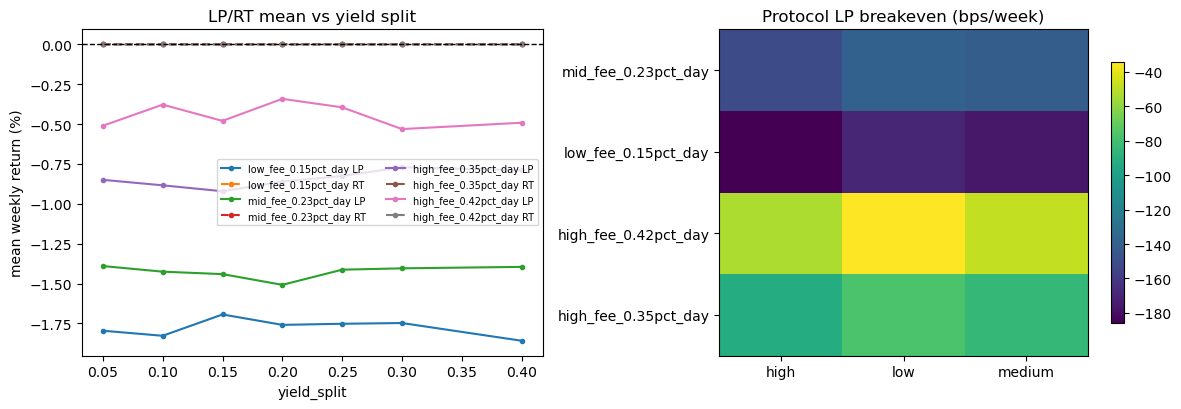

In [10]:
# 11) Compact plots

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))

for scen in fee_day_scenarios:
    d = opt_df[opt_df['scenario']==scen].sort_values('yield_split')
    ax[0].plot(d['yield_split'], d['lp_mean_%'], '-o', ms=3, label=f'{scen} LP')
    ax[0].plot(d['yield_split'], d['rt_mean_%'], '--o', ms=3, label=f'{scen} RT')
ax[0].axhline(0, ls='--', c='black', lw=1)
ax[0].set_title('LP/RT mean vs yield split')
ax[0].set_xlabel('yield_split')
ax[0].set_ylabel('mean weekly return (%)')
ax[0].legend(fontsize=7, ncol=2)

pivot = comp[comp['strategy']=='protocol_lp'].pivot_table(index='scenario', columns='rep_level', values='breakeven_bps_week', aggfunc='mean')
im = ax[1].imshow(pivot.values, origin='lower', aspect='auto', cmap='viridis')
ax[1].set_title('Protocol LP breakeven (bps/week)')
ax[1].set_xticks(range(len(pivot.columns))); ax[1].set_xticklabels(pivot.columns)
ax[1].set_yticks(range(len(pivot.index))); ax[1].set_yticklabels(pivot.index)
fig.colorbar(im, ax=ax[1], shrink=0.8)

plt.tight_layout()
fig.savefig(os.path.join(DATA_DIR,'v3_redesign_summary_plots.png'), dpi=150)
print('Saved:', os.path.join(DATA_DIR,'v3_redesign_summary_plots.png'))

## 12) Conclusions and Limitations

### 12.1 How to read the core outputs

Use:

- `v3_redesign_strategy_fee_breakeven.csv` for per-strategy break-even fee-yields,
- `v3_redesign_strategy_fee_breakeven_ranking.csv` for headline ranking.

Primary interpretation rule:

- lower required `breakeven_fee_day` => stronger hedge economics for LP.
- protocol feasibility requires **joint LP+RT non-negative means**.

### 12.2 What this evaluation supports

This notebook provides a transparent, reproducible Monte Carlo framework to test whether protocol hedging can be economically competitive against benchmark alternatives under identical CL geometry and fee accrual assumptions.

### 12.3 Key limitations (must be stated in paper)

1. Perpetual costs are modeled as fixed assumptions (`2 bps` trade cost, `1 bp/day` funding), not venue-time-series estimates.
2. Results are simulation-based (finite path count), so thresholds are approximate on the tested fee grid.
3. Viability conclusions are conditional on the sampled historical bootstrap regime and chosen model structure.
4. A `yield_split` with no feasible break-even in scan range is reported as `NaN`, not forced to feasibility.

